In [1]:
from PIL import Image
import pickle
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2, transforms

from utils.vizualizations import plot_bias_using_QQ_plot
# Set the default figure size for all plots
plt.rcParams["figure.figsize"] = (9, 8)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(88)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(88)
np.random.seed(88)

### Create Dataset

In [3]:
def get_transform(nc, convert=True):
    transform_list = []
    grayscale = (nc == 1)
    if grayscale:
        transform_list.append(transforms.Grayscale(nc))
    if convert:
        transform_list += [transforms.ToTensor()]
        if grayscale:
            transform_list += [transforms.Normalize((0.5,), (0.5,))]
        else:
            transform_list += [transforms.Normalize((0.5,)*nc, (0.5,)*nc)]
    return transforms.Compose(transform_list)

class RainfallDataset(Dataset):
    def __init__(self, pickle_file_A, pickle_file_B, input_nc, output_nc) -> None:
        super().__init__()
        self.dir_A = pickle_file_A
        self.dir_B = pickle_file_B

        with open(self.dir_A, "rb") as f:
            data_A = pickle.load(f)
            self.A_images = list(data_A.values())
        with open(self.dir_B, "rb") as f:
            data_B = pickle.load(f)
            self.B_images = list(data_B.values())

        self.A_size = len(self.A_images)
        self.B_size = len(self.B_images)
        self.transform_A = get_transform(input_nc)
        self.transform_B = get_transform(output_nc)

    def __len__(self):
        return max(self.A_size, self.B_size)

    def __getitem__(self, index):
        idx_A = index % self.A_size
        idx_B = index % self.B_size

        A_np = self.A_images[idx_A]
        B_np = self.B_images[idx_B]

        A_img = Image.fromarray(A_np)
        B_img = Image.fromarray(B_np)

        A = self.transform_A(A_img)
        B = self.transform_B(B_img)
        return A, B

#### Build models

#### Unet Style Generator

In [4]:
class Generator(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Generator, self).__init__()

        # Down part (shrink picture to learn fatures)
        self.down1 = nn.Sequential(nn.Conv2d(in_channels, 64, 4, 2, 1), nn.LeakyReLU(0.2))  # 1 channel input
        self.down2 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2))
        self.down3 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2))
        self.down4 = nn.Sequential(nn.Conv2d(256, 512, 4, 2, 1), nn.InstanceNorm2d(512), nn.LeakyReLU(0.2))
        
        # Up (build back with skips)
        self.up1 = nn.Sequential(nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.ReLU())
        self.up2 = nn.Sequential(nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU())
        self.up3 = nn.Sequential(nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU())
        self.up4 = nn.Sequential(nn.ConvTranspose2d(128, out_channels, 4, 2, 1), nn.Tanh())  # 1 channel output
        
    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        
        u1 = self.up1(d4)
        u2 = self.up2(torch.cat([u1, d3], 1))  # Skip connection
        u3 = self.up3(torch.cat([u2, d2], 1))
        u4 = self.up4(torch.cat([u3, d1], 1))

        return u4

#### Discriminator

In [5]:
class Discriminator(nn.Module):
    def __init__(self, in_channels):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels*2, 64, 4, 2, 1), nn.LeakyReLU(0.2),  # 2 channels: blurry + sharp/fake
            nn.Conv2d(64, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 1, 1), nn.InstanceNorm2d(512), nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1, 4, 1, 1) # Real/fake per patch
        )

    def forward(self, x, y):
        return self.model(torch.cat([x, y], 1)) # combine blurry (x) and nice/faake (y)

#### Train the GAN

In [6]:
INPUT_NC = 1
OUTPUT_NC = 1
EPOCHS = 15
BATCH_SIZE = 16
LEARNING_RATE_G = 0.0002
LEARNING_RATE_D = 0.00002
BETA_1, BETA_2 = 0.5, 0.999
START_DECAY_EPOCH = EPOCHS // 2
PICKLE_FILE_PATH_A = "./data/filterd_chirps_reprojected.pkl"
PICKLE_FILE_PATH_B = "./data/filtered_chirps.pkl"

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator(INPUT_NC, OUTPUT_NC).to(device)
discriminator = Discriminator(INPUT_NC).to(device)

In [8]:
dataset = RainfallDataset(PICKLE_FILE_PATH_A, PICKLE_FILE_PATH_B, INPUT_NC, OUTPUT_NC)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, num_workers=4)

gan_loss = nn.BCEWithLogitsLoss() # Binary Cross Entropy. For real/fake game
l1_loss = nn.L1Loss() # To make generated close to real
mse_loss = nn.MSELoss()

g_optimizer = optim.Adam(generator.parameters(), lr=LEARNING_RATE_G, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE_D, betas=(0.5, 0.999))

In [9]:
d_loss_history = []
g_loss_history = []
start_time = time.time()
for epoch in range(EPOCHS):
    # epoch_start_time = time.time()
    g_loss_train = 0.0
    d_loss_train = 0.0
    for low, high in tqdm(dataloader,  desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True, colour="#42a5f5"):
        low, high = low.to(device), high.to(device)

        for param in discriminator.parameters():
            param.requires_grad = True
        # Train Discriminator (judge real vs fake)
        fake = generator(low)
        real_pred = discriminator(low, high)
        fake_pred = discriminator(low, fake.detach())
        d_real_loss = gan_loss(real_pred, torch.ones_like(real_pred))
        d_fake_loss = gan_loss(fake_pred, torch.zeros_like(fake_pred))
        d_loss = (d_real_loss + d_fake_loss)
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train Generator (make better fakes)
        for param in discriminator.parameters():
            param.requires_grad = False
        fake_pred = discriminator(low, fake)
        g_gan_loss = gan_loss(fake_pred, torch.ones_like(fake_pred))
        g_l1_loss = l1_loss(fake, high) * 100
        g_loss = g_gan_loss + g_l1_loss
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        g_loss_train += g_loss.item()
        d_loss_train += d_loss.item()
        
    g_loss_history.append(g_loss_train)
    d_loss_history.append(d_loss_train)
    tqdm.write(f"D_loss: {d_loss_train:0.3f} G_loss: {g_loss_train:0.3f}")

Epoch 1/15: 100%|██████████| 43/43 [00:01<00:00, 33.76it/s]


D_loss: 21.655 G_loss: 1465.620


Epoch 2/15: 100%|██████████| 43/43 [00:00<00:00, 73.82it/s]


D_loss: 3.880 G_loss: 1118.177


Epoch 3/15: 100%|██████████| 43/43 [00:00<00:00, 74.08it/s]


...

D_loss: 0.152 G_loss: 508.018


Epoch 14/15: 100%|██████████| 43/43 [00:00<00:00, 74.42it/s]


D_loss: 0.137 G_loss: 511.607


Epoch 15/15: 100%|██████████| 43/43 [00:00<00:00, 71.88it/s]

D_loss: 0.121 G_loss: 513.717


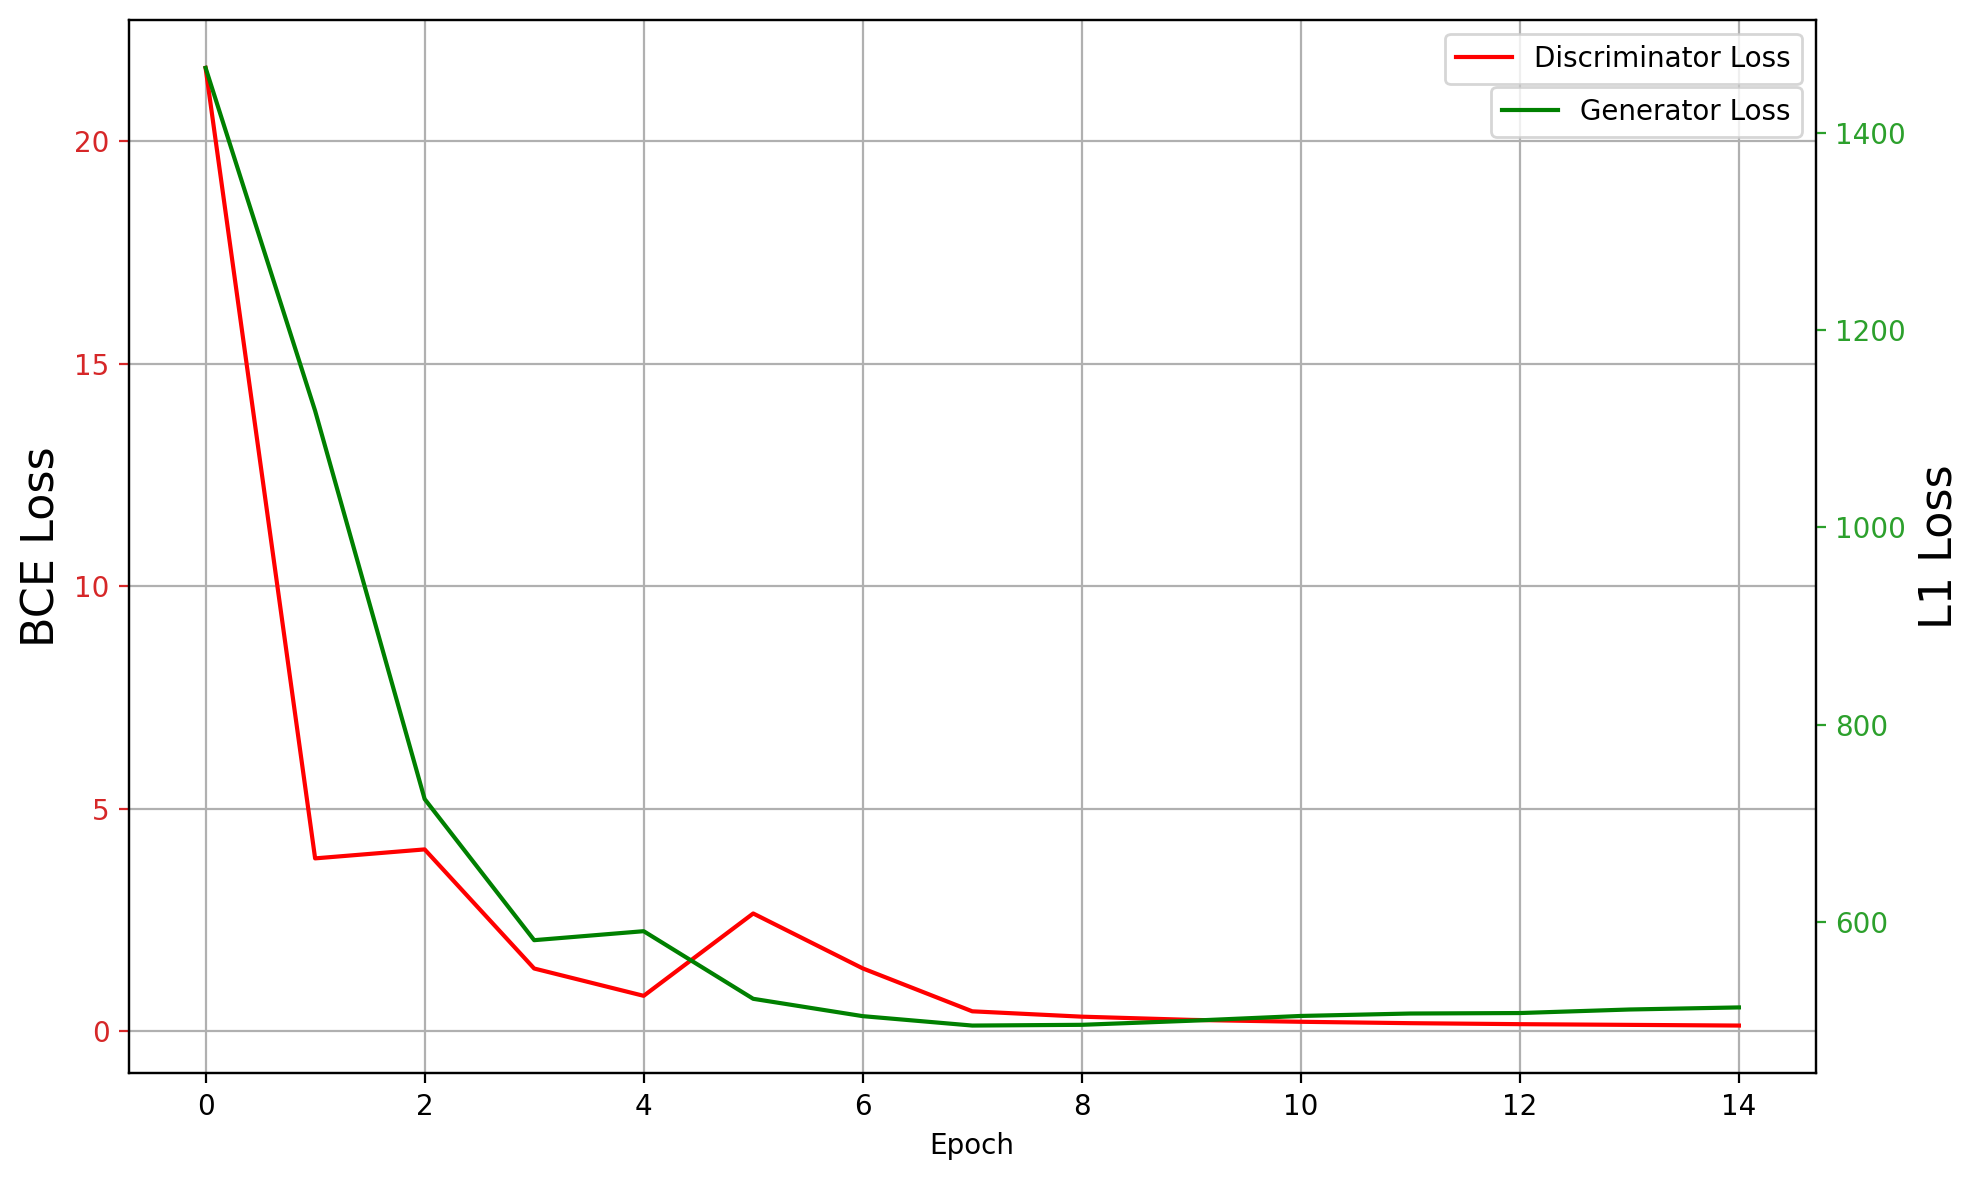

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=200)
ax1.plot(d_loss_history, "r", label='Discriminator Loss')
ax1.tick_params(axis="y", labelcolor="tab:red", color="tab:red")
ax1.set_ylabel("BCE Loss", fontsize=16)
ax1.legend(loc="upper right", bbox_to_anchor=[1, 1])
ax1.set_xlabel("Epoch")

ax2 = ax1.twinx() # Instatiate a second Axes that shares the x-axis

ax2.plot(g_loss_history, "g", label='Generator Loss')
ax2.tick_params(axis="y", labelcolor="tab:green", color="tab:green")
ax2.set_ylabel("L1 Loss", fontsize=16)
ax2.legend(loc='best', bbox_to_anchor=(1, 0.95))
ax1.grid(True)
plt.tight_layout()

### Testing

In [11]:
def tensor2im(input_image, imtype=np.uint8):
    """ "Converts a Tensor array into a numpy image array.

    Parameters:
        input_image (tensor) --  the input image tensor array
        imtype (type)        --  the desired type of the converted numpy array
    """
    if not isinstance(input_image, np.ndarray):
        if isinstance(input_image, torch.Tensor):  # get the data from a variable
            image_tensor = input_image.data
        else:
            return input_image
        image_numpy = image_tensor[0].cpu().float().numpy()  # convert it into a numpy array
        if image_numpy.shape[0] == 1:  # grayscale to RGB
            image_numpy = np.tile(image_numpy, (3, 1, 1))
            # image_numpy = image_numpy[0]
        image_numpy = (np.transpose(image_numpy, (1, 2, 0)) + 1) / 2.0 * 255.0  # post-processing: tranpose and scaling
        # Denormalize and scale
        # image_numpy = (image_numpy+ 1) / 2.0 * 255.0
    else:  # if it is a numpy array, do nothing
        image_numpy = input_image
    return image_numpy.astype(imtype)

In [12]:
generator.eval()
pred_images = []
real_images = []
with torch.inference_mode():
    for A, B in dataloader:
        real_A = A.to(device)
        real_B = B.to(device)
        fake_B = generator(real_A)
        
        img_in = Image.fromarray(tensor2im(A)).convert("L")
        img_fake = Image.fromarray(tensor2im(fake_B)).convert("L")
        fake_B = tensor2im(fake_B)
        fake_B[fake_B > 249.0] = 0.0
        img_fake = Image.fromarray(fake_B).convert("L")
        real_B = Image.fromarray(tensor2im(real_B)).convert("L")
        pred_images.append(img_fake)
        real_images.append(real_B)
pred_images = np.array(pred_images)
real_images = np.array(real_images)

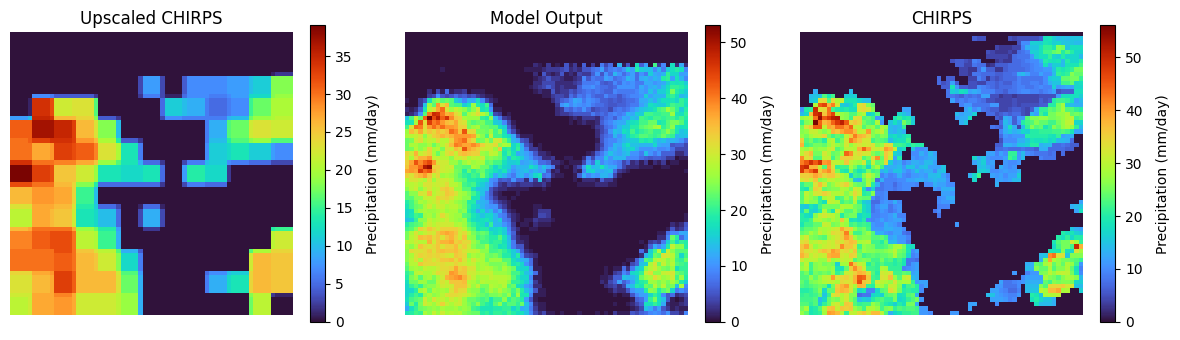

In [30]:
generator.eval()
with torch.inference_mode():
    # A, B = next(iter(dataloader))
    for A, B in dataloader:
        real_A = A.to(device)
        real_B = B.to(device)
        fake_B = generator(real_A)
        
        img_in = Image.fromarray(tensor2im(A)).convert("L")
        fake_B = tensor2im(fake_B)
        fake_B[fake_B > 249.0] = 0.0
        img_fake = Image.fromarray(fake_B).convert("L")
        real_B = Image.fromarray(tensor2im(real_B)).convert("L")

        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        fig = axs[0].imshow(img_in, cmap="turbo"); axs[0].set_title("Upscaled CHIRPS")
        cbar = plt.colorbar(fig, ax=axs[0], shrink=0.8)
        cbar.set_label('Precipitation (mm/day)', labelpad=10)
        
        fig = axs[1].imshow(img_fake, cmap="turbo"); axs[1].set_title("Model Output")
        cbar = plt.colorbar(fig, ax=axs[1], shrink=0.8)
        cbar.set_label('Precipitation (mm/day)', labelpad=10)

        fig = axs[2].imshow(real_B, cmap="turbo"); axs[2].set_title("CHIRPS")
        cbar = plt.colorbar(fig, ax=axs[2], shrink=0.8)
        cbar.set_label('Precipitation (mm/day)', labelpad=10)

        for ax in axs: ax.axis("off")
        plt.tight_layout()
        break

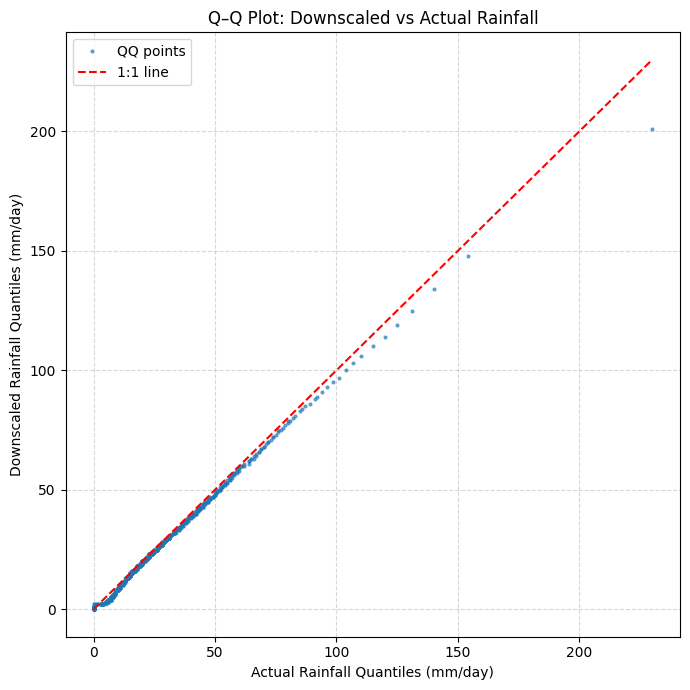

Mean Bias: 77.103
RMSE: 5.448


In [14]:
plot_bias_using_QQ_plot(pred_images, real_images)